# Chess Elo Prediction — Per-Player Aggregation

**Hypothesis**: an Elo is a *distribution*, not a point. A single game is a noisy sample of a player's strength. If we aggregate many games for the same player and predict their **average Elo** from **averaged game features**, the estimate should be more accurate than per-game prediction.

This notebook:
1. Loads games **keeping the player usernames** (`White`/`Black`), which the original loader dropped.
2. Builds per-game features (clock + board via `chess_features_final.py`).
3. Reshapes to one row **per (player, game)**, keeping that player's Elo and the colour-agnostic feature view.
4. Keeps only players with **more than `MIN_GAMES_PER_PLAYER`** games, aggregates their features (mean/std/count), and predicts their **mean Elo**.
5. Compares per-player MAE against a per-game baseline, and shows how accuracy improves as a player's game count rises.

In [2]:
import io, re, time, os, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zstandard as zstd
import lightgbm as lgb
from joblib import Parallel, delayed
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from chess_features_final import extract_features_dataframe
warnings.filterwarnings('ignore', message='X does not have valid feature names')
print('Imports OK')

Imports OK


## 0 · CONFIG

In [3]:
DATA_PATH    = '../../data/villads_data/lichess_db_standard_rated_2017-11.pgn.zst'
MAX_GAMES    = 500_000        # more games -> more players with repeats
RANDOM_STATE = 42
N_JOBS       = -1
FILTER_BASE_SECONDS = 600
MIN_TOTAL_PLIES      = 12
EXCLUDE_TERMINATIONS = {'Abandoned', 'Unterminated'}

MIN_GAMES_PER_PLAYER = 4      # 'more than 3 games' => >= 4
TEST_SIZE = 0.20

# colour-agnostic per-player features (mean over a player's games). 'own' = that player's side.
PLAYER_FEATURES = [
    'total_ply_count','checks_given_own','check_density_own','first_capture_move_own',
    'pawn_captures_total','piece_captures_total','capture_density',
    'castle_move_own','consec_same_piece_own','queen_moves_before_10','territory_depth_own',
    'promotions','legal_moves_own_move5',
    'avg_time_norm_own','std_time_norm_own','max_time_norm_own','time_pressure_own',
    'opening_pace_norm_own','clock_remaining_norm_own','time_spent_trend_norm_own',
]

LGBM_PARAMS = dict(objective='regression_l1', n_estimators=800, learning_rate=0.05,
                   num_leaves=63, min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                   random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS)

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
_TS = datetime.now().strftime('%Y%m%d_%H%M%S')
print('Config loaded:', _TS)

Config loaded: 20260608_120813


## 1 · Load games keeping player names
The original loader only kept Elo/Moves. Here we also capture the `White` and `Black` username tags so we can group by player.

In [4]:
def load_games_with_players(path, max_games):
    games, dctx = [], zstd.ZstdDecompressor()
    keep = ('White','Black','WhiteElo','BlackElo','TimeControl','ECO','Termination','Result')
    t0 = time.time()
    with open(path, 'rb') as cf:
        with dctx.stream_reader(cf) as reader:
            stream = io.TextIOWrapper(reader, encoding='utf-8')
            cur = {}
            for line in stream:
                line = line.strip()
                if line.startswith('['):
                    tag = line.split(' ')[0][1:]
                    if tag in keep:
                        # value is the first quoted substring
                        parts = line.split('"')
                        if len(parts) > 1:
                            cur[tag] = parts[1]
                elif line and line[0].isdigit() and '.' in line[:4]:
                    cur['Moves'] = line
                    if 'WhiteElo' in cur and 'BlackElo' in cur and 'White' in cur and 'Black' in cur:
                        games.append(cur)
                    cur = {}
                    if len(games) >= max_games: break
    df = pd.DataFrame(games)
    for c in ('WhiteElo','BlackElo'):
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['WhiteElo','BlackElo','White','Black']).copy()
    df['WhiteElo'] = df['WhiteElo'].astype(int); df['BlackElo'] = df['BlackElo'].astype(int)
    df['Moves'] = df['Moves'].fillna('').astype(str)
    print(f'Loaded {len(df):,} games in {time.time()-t0:.1f}s')
    return df

df_all = load_games_with_players(DATA_PATH, MAX_GAMES)
df_all[['White','Black','WhiteElo','BlackElo','TimeControl']].head(3)

Loaded 500,000 games in 34.3s


,White,Black,WhiteElo,BlackElo,TimeControl
0,emaema,hazretpolat,1391,1411,600+0
1,Luisnn,tomatjuice123,1626,1620,180+0
2,TheGrim123321,PaddyCologne,1374,1350,600+0


## 2 · Per-game features (clock + board)

In [5]:
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+)\]')
def parse_clock_features(moves_string, time_control='?'):
    clocks = [int(h)*3600 + int(m)*60 + int(s) for h, m, s in _CLK_RE.findall(moves_string)]
    clk_w, clk_b = clocks[0::2], clocks[1::2]
    tc_m  = re.match(r'(\d+)\+(\d+)', str(time_control)); base = int(tc_m.group(1)) if tc_m else None
    inc = int(tc_m.group(2)) if tc_m else 0; norm = base if base else 1
    def _spent(seq, start):
        out, prev = [], start
        for c in seq:
            if prev is not None:
                s = prev - c + inc
                if s >= 0: out.append(s)
            prev = c
        return out
    sw, sb = _spent(clk_w, base), _spent(clk_b, base)
    def _stats(seq):
        if not seq: return 0.,0.,0.
        a=np.array(seq); return float(a.mean()), float(a.std()), float(a.max())
    def _trend(seq):
        if len(seq)<2: return 0.0
        return float(np.polyfit(np.arange(len(seq)), np.array(seq,float),1)[0])
    aw,sw2,mw=_stats(sw); ab,sb2,mb=_stats(sb)
    return {
        'avg_time_norm_white':aw/norm,'std_time_norm_white':sw2/norm,'max_time_norm_white':mw/norm,
        'time_pressure_white':sum(1 for c in clk_w if c<10),'opening_pace_norm_white':(np.mean(sw[:10]) if sw else 0.)/norm,
        'clock_remaining_norm_white':(clk_w[-1]/norm) if clk_w else 0.,'time_spent_trend_norm_white':_trend(sw)/norm,
        'avg_time_norm_black':ab/norm,'std_time_norm_black':sb2/norm,'max_time_norm_black':mb/norm,
        'time_pressure_black':sum(1 for c in clk_b if c<10),'opening_pace_norm_black':(np.mean(sb[:10]) if sb else 0.)/norm,
        'clock_remaining_norm_black':(clk_b[-1]/norm) if clk_b else 0.,'time_spent_trend_norm_black':_trend(sb)/norm,
    }

df = df_all.copy()
if FILTER_BASE_SECONDS is not None:
    base = df['TimeControl'].astype(str).str.extract(r'^(\d+)\+')[0].astype(float)
    df = df[base == FILTER_BASE_SECONDS].copy().reset_index(drop=True)
if EXCLUDE_TERMINATIONS and 'Termination' in df.columns:
    df = df[~df['Termination'].isin(EXCLUDE_TERMINATIONS)].copy().reset_index(drop=True)
print('After filters:', len(df), 'games')

t0 = time.time()
recs = Parallel(n_jobs=N_JOBS)(delayed(parse_clock_features)(m,t) for m,t in zip(df['Moves'], df['TimeControl']))
clk = pd.DataFrame(recs, index=df.index)
feats = extract_features_dataframe(df, n_jobs=N_JOBS)
g = df[['White','Black','WhiteElo','BlackElo']].join(feats).join(clk).replace([np.inf,-np.inf], np.nan)
if 'total_ply_count' in g.columns:
    g = g[g['total_ply_count'] >= MIN_TOTAL_PLIES].copy().reset_index(drop=True)
print(f'Per-game features built in {time.time()-t0:.1f}s | {g.shape}')

After filters: 71063 games
Per-game features built in 119.0s | (69799, 53)


## 3 · Reshape to one row per (player, game) with colour-agnostic 'own' features
Each game contributes two rows: one for White (own = white-side stats) and one for Black (own = black-side stats). This lets us aggregate per player regardless of which colour they played.

In [6]:
def side_view(g, colour):
    me, opp = (colour, 'black' if colour=='white' else 'white')
    out = pd.DataFrame(index=g.index)
    out['player'] = g['White'] if colour=='white' else g['Black']
    out['elo']    = g['WhiteElo'] if colour=='white' else g['BlackElo']
    out['total_ply_count'] = g['total_ply_count']
    out['pawn_captures_total'] = g['pawn_captures_total']
    out['piece_captures_total'] = g['piece_captures_total']
    out['capture_density'] = g['capture_density']
    out['promotions'] = g['promotions']
    out['queen_moves_before_10'] = g['queen_moves_before_10']
    out['checks_given_own'] = g[f'checks_given_{me}']
    out['check_density_own'] = g[f'check_density_{me}']
    out['first_capture_move_own'] = g[f'first_capture_move_{me}']
    out['castle_move_own'] = g[f'castle_move_{me}']
    out['consec_same_piece_own'] = g[f'consec_same_piece_{me}']
    out['territory_depth_own'] = g[f'{me}_territory_depth']
    out['legal_moves_own_move5'] = g[f'legal_moves_{me}_move5']
    for base_ in ['avg_time_norm','std_time_norm','max_time_norm','time_pressure','opening_pace_norm','clock_remaining_norm','time_spent_trend_norm']:
        out[f'{base_}_own'] = g[f'{base_}_{me}']
    return out

long = pd.concat([side_view(g,'white'), side_view(g,'black')], ignore_index=True)
long = long.dropna(subset=['player','elo'])
print('Player-game rows:', len(long), '| unique players:', long['player'].nunique())

Player-game rows: 139598 | unique players: 26205


## 4 · Keep players with > 3 games, aggregate features

In [7]:
counts = long.groupby('player')['elo'].count()
eligible = counts[counts >= MIN_GAMES_PER_PLAYER].index
sub = long[long['player'].isin(eligible)].copy()
print(f'{len(eligible):,} players with >= {MIN_GAMES_PER_PLAYER} games  ({len(sub):,} player-game rows)')

feat_cols = [c for c in PLAYER_FEATURES if c in sub.columns]
agg = sub.groupby('player').agg(
    n_games=('elo','size'),
    elo_mean=('elo','mean'),
    elo_std=('elo','std'),
    **{f'{c}_mean': (c,'mean') for c in feat_cols},
    **{f'{c}_std':  (c,'std')  for c in feat_cols},
)
agg['elo_std'] = agg['elo_std'].fillna(0.0)
X_cols = [c for c in agg.columns if c.endswith('_mean') or c.endswith('_std')]
X_cols = [c for c in X_cols if c != 'elo_mean']
X_cols += ['n_games']
print('Aggregated players:', agg.shape, '| feature cols:', len(X_cols))
agg[['n_games','elo_mean','elo_std']].describe().round(1)

12,126 players with >= 4 games  (115,365 player-game rows)
Aggregated players: (12126, 43) | feature cols: 42


,n_games,elo_mean,elo_std
count,12126.0,12126.0,12126.0
mean,9.5,1524.2,16.3
std,7.1,259.3,19.0
min,4.0,791.4,0.0
25%,5.0,1341.0,8.6
50%,7.0,1530.2,11.8
75%,11.0,1709.6,16.6
max,79.0,2385.3,249.1


Median within-player Elo std: 11.8


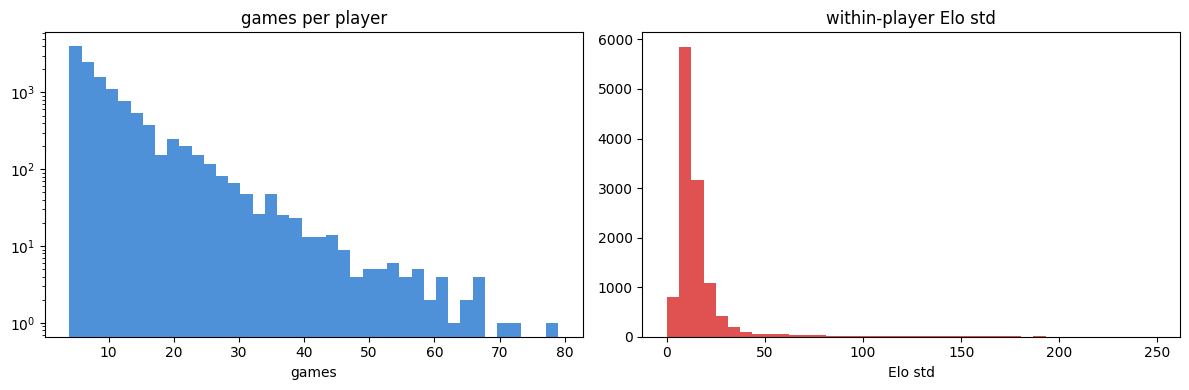

In [8]:
# How much does a single game's Elo vary around the player's own mean? (motivates aggregation)
print(f"Median within-player Elo std: {agg['elo_std'].median():.1f}")
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].hist(agg['n_games'], bins=40, color='#4e91d9'); ax[0].set_title('games per player'); ax[0].set_xlabel('games'); ax[0].set_yscale('log')
ax[1].hist(agg['elo_std'], bins=40, color='#e05252'); ax[1].set_title('within-player Elo std'); ax[1].set_xlabel('Elo std')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/player_distribution_{_TS}.png', dpi=110); plt.show()

## 5 · Train per-player model + compare to per-game baseline
Split is done **by player** so no player appears in both train and test (avoids leakage). The per-game baseline trains on individual rows and is then evaluated by averaging its per-game predictions for each test player — a fair, like-for-like comparison.

In [9]:
players = agg.index.values
tr_players, te_players = train_test_split(players, test_size=TEST_SIZE, random_state=RANDOM_STATE)
tr_mask = agg.index.isin(tr_players); te_mask = agg.index.isin(te_players)

Xtr = agg.loc[tr_mask, X_cols]; ytr = agg.loc[tr_mask, 'elo_mean']
Xte = agg.loc[te_mask, X_cols]; yte = agg.loc[te_mask, 'elo_mean']

player_model = Pipeline([('impute', SimpleImputer(strategy='median')), ('lgbm', lgb.LGBMRegressor(**LGBM_PARAMS))])
player_model.fit(Xtr, ytr)
pp = player_model.predict(Xte)
player_mae = mean_absolute_error(yte, pp)
print(f'PER-PLAYER  MAE {player_mae:.1f} | RMSE {root_mean_squared_error(yte, pp):.1f} | R2 {r2_score(yte, pp):.3f}')

PER-PLAYER  MAE 142.7 | RMSE 183.2 | R2 0.521


In [10]:
# Per-game baseline trained on individual games (players disjoint from test players)
game_feat_cols = feat_cols  # raw 'own' per-game features
g_tr = sub[sub['player'].isin(tr_players)]
g_te = sub[sub['player'].isin(te_players)]

game_model = Pipeline([('impute', SimpleImputer(strategy='median')), ('lgbm', lgb.LGBMRegressor(**LGBM_PARAMS))])
game_model.fit(g_tr[game_feat_cols], g_tr['elo'])

# 1) raw per-game MAE
g_pred = game_model.predict(g_te[game_feat_cols])
per_game_mae = mean_absolute_error(g_te['elo'], g_pred)

# 2) aggregate per-game predictions to player level (average the noisy guesses)
g_te = g_te.assign(pred=g_pred)
agg_game_pred = g_te.groupby('player')['pred'].mean()
true_mean = g_te.groupby('player')['elo'].mean()
common = agg_game_pred.index.intersection(true_mean.index)
per_game_agg_mae = mean_absolute_error(true_mean[common], agg_game_pred[common])

print(f'PER-GAME (raw, single game)       MAE {per_game_mae:.1f}')
print(f'PER-GAME predictions averaged     MAE {per_game_agg_mae:.1f}')
print(f'PER-PLAYER (aggregated features)  MAE {player_mae:.1f}')

PER-GAME (raw, single game)       MAE 183.3
PER-GAME predictions averaged     MAE 163.9
PER-PLAYER (aggregated features)  MAE 142.7


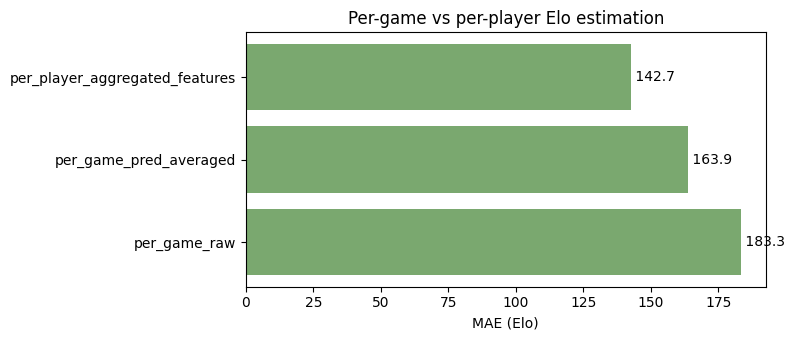

,approach,MAE
2,per_player_aggregated_features,142.73
1,per_game_pred_averaged,163.87
0,per_game_raw,183.32


In [11]:
summary = pd.DataFrame([
    {'approach':'per_game_raw', 'MAE':per_game_mae},
    {'approach':'per_game_pred_averaged', 'MAE':per_game_agg_mae},
    {'approach':'per_player_aggregated_features', 'MAE':player_mae},
]).sort_values('MAE')
summary.to_csv(f'{RESULTS_DIR}/per_player_comparison_{_TS}.csv', index=False)
fig, ax = plt.subplots(figsize=(8,3.5))
p = summary.sort_values('MAE', ascending=False)
ax.barh(p['approach'], p['MAE'], color='#7aa86f')
for i,(a,v) in enumerate(zip(p['approach'], p['MAE'])): ax.text(v,i,f' {v:.1f}',va='center')
ax.set_xlabel('MAE (Elo)'); ax.set_title('Per-game vs per-player Elo estimation')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/per_player_comparison_{_TS}.png', dpi=110); plt.show()
summary.round(2)

## 6 · Does more games per player => better estimate?
Bucket test players by their game count and plot per-player MAE. If the hypothesis holds, MAE should fall as game count rises.

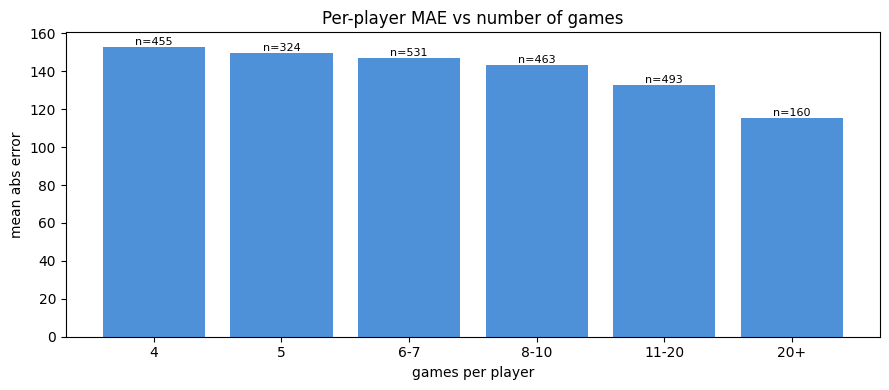

         mean  count
bucket              
4       152.9    455
5       149.7    324
6-7     147.1    531
8-10    143.1    463
11-20   132.6    493
20+     115.3    160


In [12]:
te = agg.loc[te_mask].copy()
te['pred'] = pp
te['abs_err'] = np.abs(te['elo_mean'] - te['pred'])
bins = [3, 4, 5, 7, 10, 20, 10_000]
labels = ['4','5','6-7','8-10','11-20','20+']
te['bucket'] = pd.cut(te['n_games'], bins=bins, labels=labels)
by_bucket = te.groupby('bucket', observed=True)['abs_err'].agg(['mean','count'])
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(by_bucket.index.astype(str), by_bucket['mean'], color='#4e91d9')
for i,(m,c) in enumerate(zip(by_bucket['mean'], by_bucket['count'])): ax.text(i, m, f'n={c}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('games per player'); ax.set_ylabel('mean abs error'); ax.set_title('Per-player MAE vs number of games')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/mae_vs_gamecount_{_TS}.png', dpi=110); plt.show()
print(by_bucket.round(1).to_string())